In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt 
import matplotlib as mpl
import seaborn as sns

from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split, GroupShuffleSplit 

import glob, sys, os, math, gc, sklearn, scipy, json 

print(f'Tensorflow V{tf.__version__}')
print(f'Keras V{tf.keras.__version__}')
print(f'Python V{sys.version}') 

2026-03-04 14:10:08.473653: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772633408.657698      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772633408.717529      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772633409.150575      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772633409.150620      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772633409.150622      24 computation_placer.cc:177] computation placer alr

Tensorflow V2.19.0
Keras V3.10.0
Python V3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [2]:
# MatplotLib Global Settings
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['xtick.labelsize'] = 16
mpl.rcParams['ytick.labelsize'] = 16
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['axes.titlesize'] = 24 

In [3]:
# Set to True because the preprocessing logic was changed (added motion features) 
PREPROCESS_DATA = True 
TRAIN_MODEL = True
USE_VAL = True

# Mixed Precision on GPU P100 for faster training, 50% less VRAM usage
from tensorflow.keras import mixed_precision
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

# Data Dimensions
N_ROWS = 543
N_DIMS = 3
DIM_NAMES = ['x', 'y', 'z']
SEED = 42
NUM_CLASSES = 250
IS_INTERACTIVE = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '') == 'Interactive'
VERBOSE = 1 if IS_INTERACTIVE else 2

# INPUT CONFIGURATION
# Increased to 128 to capture fine temporal details (fingerspelling)
INPUT_SIZE = 128 

# Training Hyperparameters
BATCH_ALL_SIGNS_N = 4
BATCH_SIZE = 64
N_EPOCHS = 200 # 100
LR_MAX = 4e-4 #1e-3
N_WARMUP_EPOCHS = 10 # Slight warmup helps Transformer stability
WD_RATIO = 0.05
MASK_VAL = 0.0 

# Data type config
DATA_DTYPE = np.float16

print(f'Compute Policy: {policy.compute_dtype}')
print(f'Variable Policy: {policy.variable_dtype}')

Compute Policy: float16
Variable Policy: float32


In [4]:
# Prints Shape and Dtype For List Of Variables
def print_shape_dtype(l, names):
    for e, n in zip(l, names):
        print(f'{n} shape: {e.shape}, dtype: {e.dtype}') 

In [5]:
# Read Training Data
#if IS_INTERACTIVE or not PREPROCESS_DATA:
#train = pd.read_csv('/kaggle/input/asl-signs/train.csv').sample(int(5e3), random_state=SEED)
#else:
train = pd.read_csv('/kaggle/input/competitions/asl-signs/train.csv')

N_SAMPLES = len(train)
print(f'N_SAMPLES: {N_SAMPLES}') 

N_SAMPLES: 94477


In [6]:
# Get complete file path to file
def get_file_path(path):
    return f'/kaggle/input/competitions/asl-signs/{path}'

train['file_path'] = train['path'].apply(get_file_path) 

# Encoding Labels

In [7]:
MAP_PATH = '/kaggle/input/competitions/asl-signs/sign_to_prediction_index_map.json'

with open(MAP_PATH, 'r') as f:
    SIGN2ORD = json.load(f)

ORD2SIGN = {v: k for k, v in SIGN2ORD.items()}

train['sign_ord'] = train['sign'].map(SIGN2ORD)

assert train['sign_ord'].isna().sum() == 0, "Mapping failed: Some signs in train are missing from the JSON map."

In [8]:
display(train.sample(n=5)) 
display(train.info()) 

,path,participant_id,sequence_id,sign,file_path,sign_ord
35631,train_landmark_files/55372/2458023945.parquet,55372,2458023945,time,/kaggle/input/competitions/asl-signs/train_lan...,220
37318,train_landmark_files/61333/2525677981.parquet,61333,2525677981,chair,/kaggle/input/competitions/asl-signs/train_lan...,40
61590,train_landmark_files/62590/3524850493.parquet,62590,3524850493,potty,/kaggle/input/competitions/asl-signs/train_lan...,176
43502,train_landmark_files/32319/2778027047.parquet,32319,2778027047,find,/kaggle/input/competitions/asl-signs/train_lan...,78
79697,train_landmark_files/28656/4260315503.parquet,28656,4260315503,wet,/kaggle/input/competitions/asl-signs/train_lan...,235


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94477 entries, 0 to 94476
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   path            94477 non-null  object
 1   participant_id  94477 non-null  int64 
 2   sequence_id     94477 non-null  int64 
 3   sign            94477 non-null  object
 4   file_path       94477 non-null  object
 5   sign_ord        94477 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 4.3+ MB


None

# EDA

In [9]:
N = int(1e3) if (IS_INTERACTIVE or not PREPROCESS_DATA) else int(10e3)
N_UNIQUE_FRAMES = np.zeros(N, dtype=np.uint16)
N_MISSING_FRAMES = np.zeros(N, dtype=np.uint16)
MAX_FRAME = np.zeros(N, dtype=np.uint16)

PERCENTILES = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]

for idx, file_path in enumerate(tqdm(train['file_path'].sample(N, random_state=SEED))):
    df = pd.read_parquet(file_path)
    N_UNIQUE_FRAMES[idx] = df['frame'].nunique()
    N_MISSING_FRAMES[idx] = (df['frame'].max() - df['frame'].min()) - df['frame'].nunique() + 1
    MAX_FRAME[idx] = df['frame'].max() 

  0%|          | 0/10000 [00:00<?, ?it/s]

,N_UNIQUE_FRAMES
count,10000.000000
mean,37.715800
std,44.396943
min,2.000000
1%,6.000000
5%,6.000000
25%,12.000000
50%,22.000000
75%,43.000000
95%,133.000000


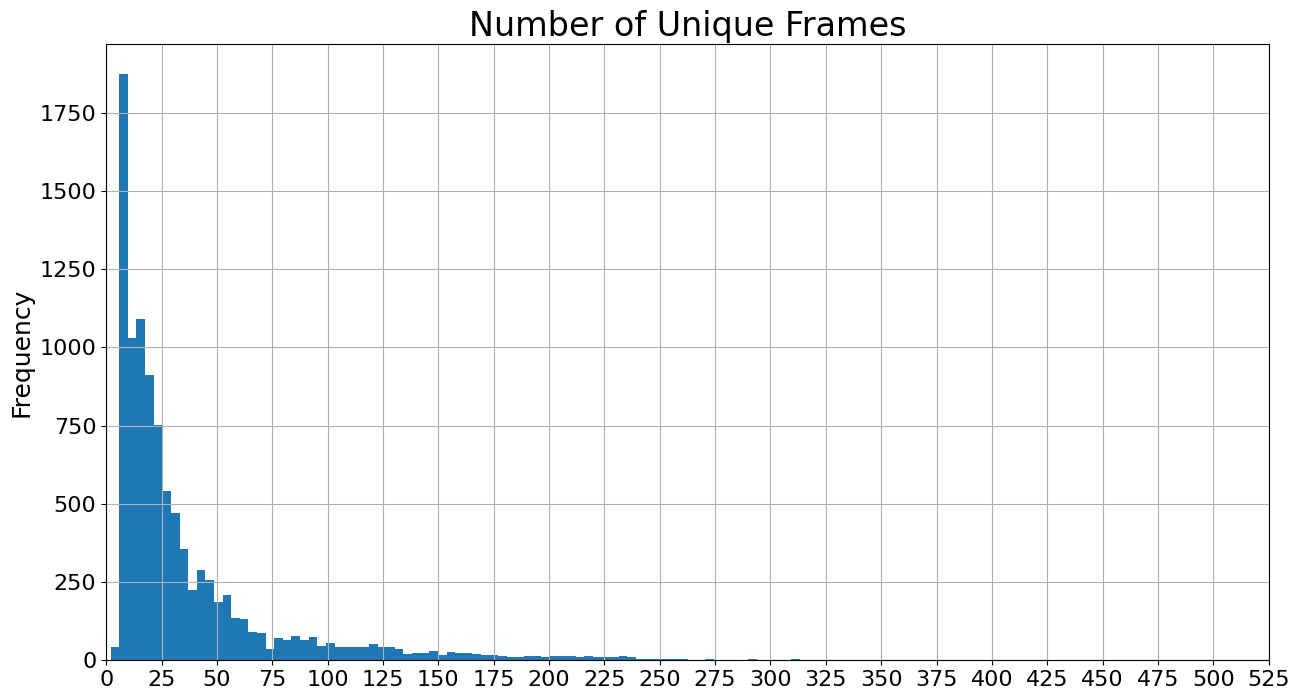

In [10]:
# Number of unique frames in each video
display(pd.Series(N_UNIQUE_FRAMES).describe(percentiles=PERCENTILES).to_frame('N_UNIQUE_FRAMES'))

plt.figure(figsize=(15,8))
plt.title('Number of Unique Frames', size=24)
pd.Series(N_UNIQUE_FRAMES).plot(kind='hist', bins=128)
plt.grid()
xlim = math.ceil(plt.xlim()[1])
plt.xlim(0, xlim)
plt.xticks(np.arange(0, xlim+25, 25))
plt.show() 

,N_MISSING_FRAMES
count,10000.000000
mean,0.004500
std,0.291699
min,0.000000
1%,0.000000
5%,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
95%,0.000000


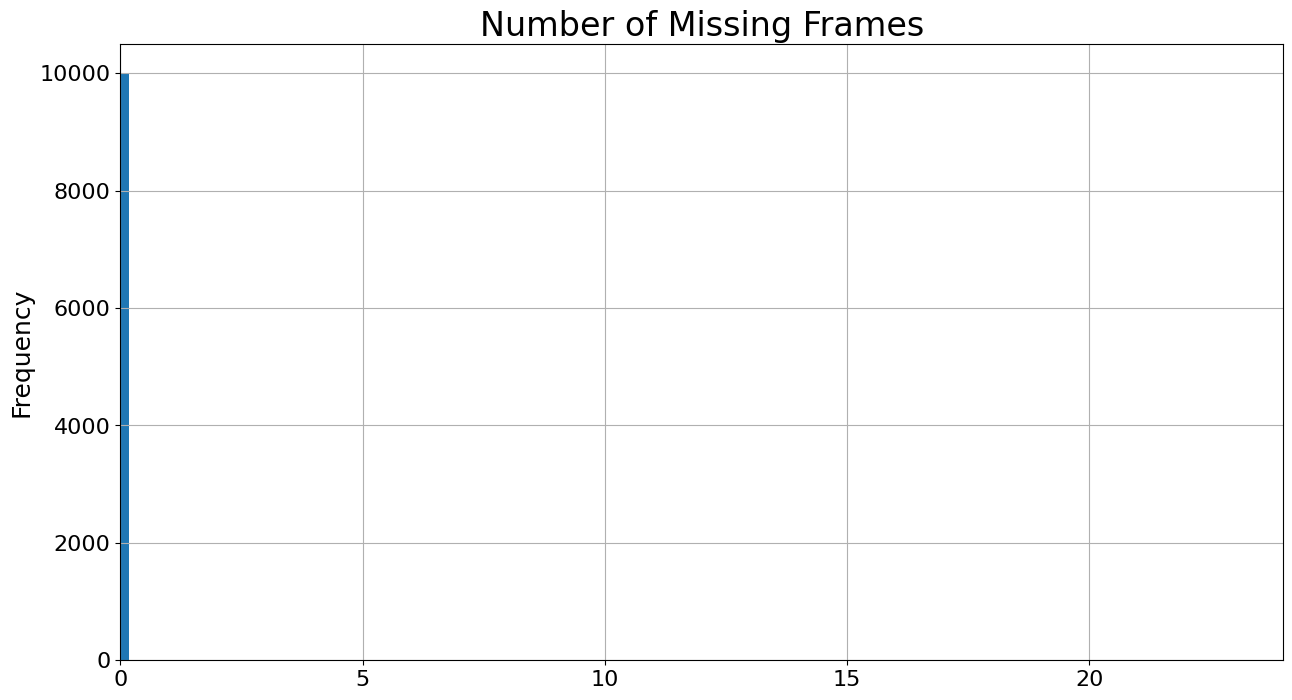

In [11]:
# Number of missing frames, consecutive frames with missing intermediate frame, i.e. 1,2,4,5 but 3 is missing
display(pd.Series(N_MISSING_FRAMES).describe(percentiles=PERCENTILES).to_frame('N_MISSING_FRAMES'))

plt.figure(figsize=(15,8))
plt.title('Number of Missing Frames', size=24)
pd.Series(N_MISSING_FRAMES).plot(kind='hist', bins=128)
plt.grid()
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

,MAX_FRAME
count,10000.000000
mean,67.391300
std,59.145194
min,1.000000
1%,12.990000
5%,22.000000
25%,33.000000
50%,42.000000
75%,63.000000
95%,201.000000


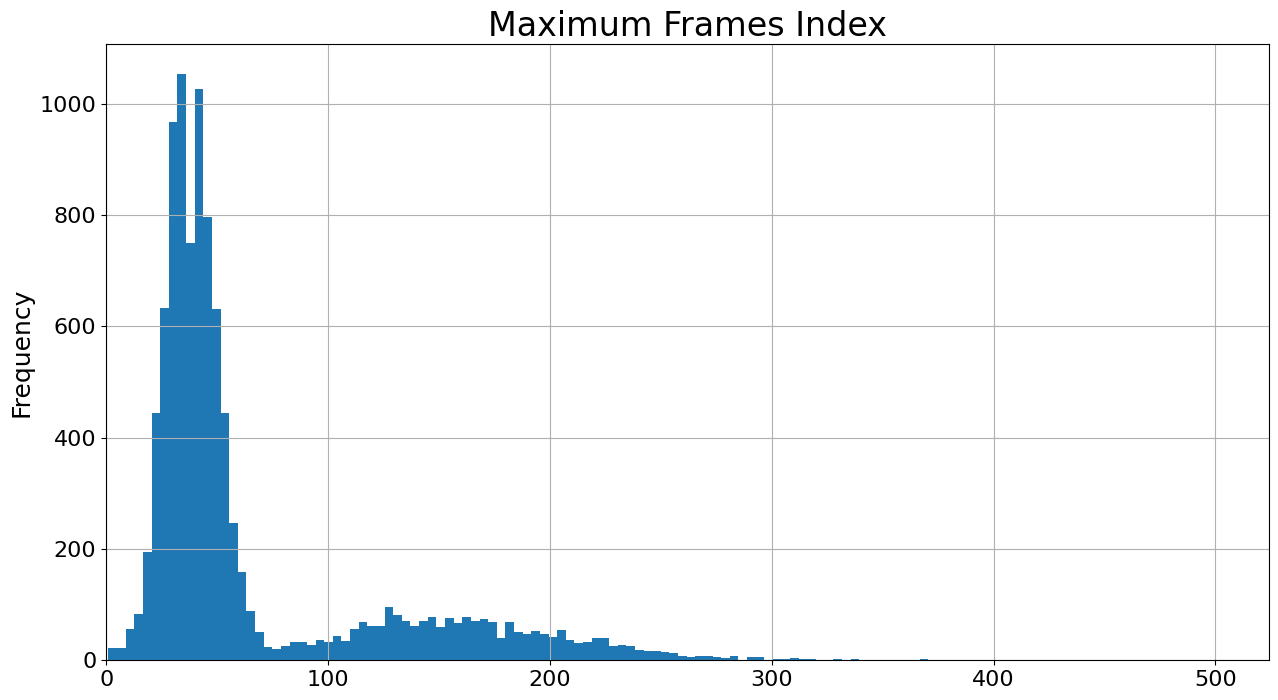

In [12]:
# Maximum frame number
display(pd.Series(MAX_FRAME).describe(percentiles=PERCENTILES).to_frame('MAX_FRAME'))

plt.figure(figsize=(15,8))
plt.title('Maximum Frames Index', size=24)
pd.Series(MAX_FRAME).plot(kind='hist', bins=128)
plt.grid() 
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

,MAX_FRAME
count,10000.000000
mean,67.391300
std,59.145194
min,1.000000
1%,12.990000
5%,22.000000
25%,33.000000
50%,42.000000
75%,63.000000
95%,201.000000


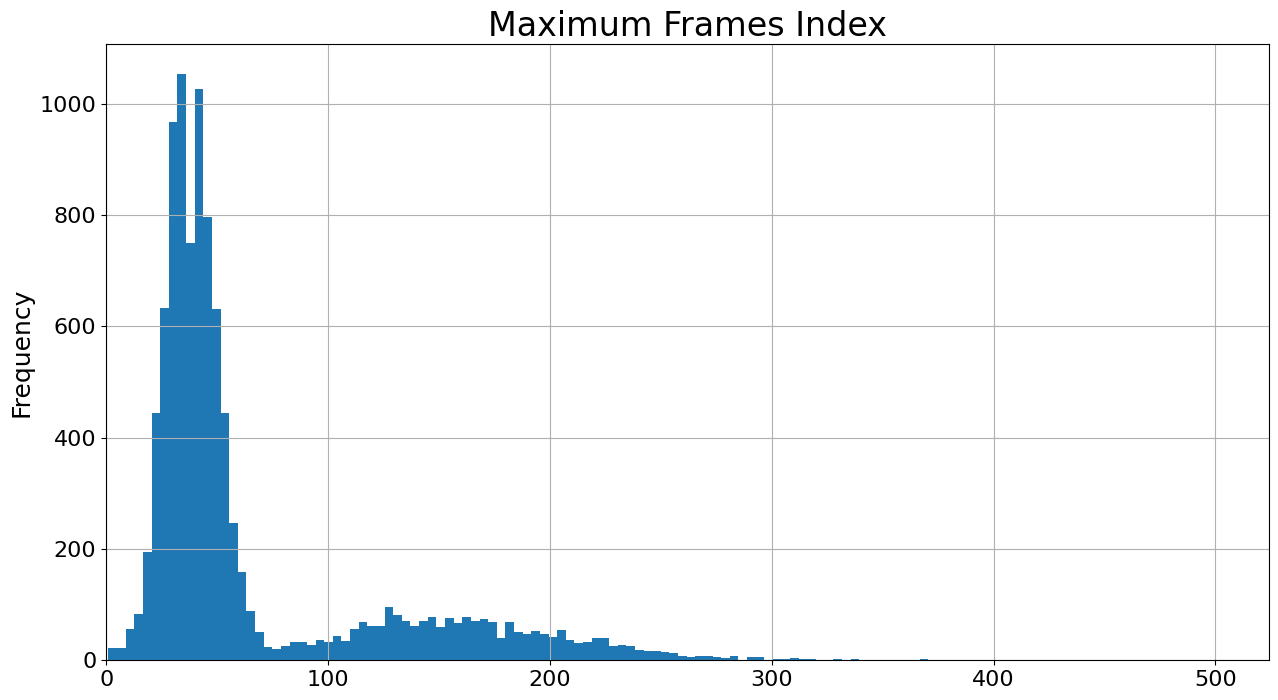

In [13]:
# Maximum frame number
display(pd.Series(MAX_FRAME).describe(percentiles=PERCENTILES).to_frame('MAX_FRAME'))

plt.figure(figsize=(15,8))
plt.title('Maximum Frames Index', size=24)
pd.Series(MAX_FRAME).plot(kind='hist', bins=128)
plt.grid() 
plt.xlim(0, math.ceil(plt.xlim()[1]))
plt.show() 

# Landmark Indices for Lips, Hands, and Pose

In [14]:
USE_TYPES = ['left_hand', 'pose', 'right_hand']
START_IDX = 468
LIPS_IDXS0 = np.array([
        61, 185, 40, 39, 37, 0, 267, 269, 270, 409,
        291, 146, 91, 181, 84, 17, 314, 405, 321, 375,
        78, 191, 80, 81, 82, 13, 312, 311, 310, 415,
        95, 88, 178, 87, 14, 317, 402, 318, 324, 308,
    ])
# Landmark indices in original data
LEFT_HAND_IDXS0 = np.arange(468,489)
RIGHT_HAND_IDXS0 = np.arange(522,543)
LEFT_POSE_IDXS0 = np.array([502, 504, 506, 508, 510])
RIGHT_POSE_IDXS0 = np.array([503, 505, 507, 509, 511])
LANDMARK_IDXS_LEFT_DOMINANT0 = np.concatenate((LIPS_IDXS0, LEFT_HAND_IDXS0, LEFT_POSE_IDXS0))
LANDMARK_IDXS_RIGHT_DOMINANT0 = np.concatenate((LIPS_IDXS0, RIGHT_HAND_IDXS0, RIGHT_POSE_IDXS0))
HAND_IDXS0 = np.concatenate((LEFT_HAND_IDXS0, RIGHT_HAND_IDXS0), axis=0)
N_COLS = LANDMARK_IDXS_LEFT_DOMINANT0.size
# Landmark indices in processed data
LIPS_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LIPS_IDXS0)).squeeze()
LEFT_HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LEFT_HAND_IDXS0)).squeeze()
RIGHT_HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, RIGHT_HAND_IDXS0)).squeeze()
HAND_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, HAND_IDXS0)).squeeze()
POSE_IDXS = np.argwhere(np.isin(LANDMARK_IDXS_LEFT_DOMINANT0, LEFT_POSE_IDXS0)).squeeze()

print(f'# HAND_IDXS: {len(HAND_IDXS)}, N_COLS: {N_COLS}') 

# HAND_IDXS: 21, N_COLS: 66


In [15]:
LIPS_START = 0
LEFT_HAND_START = LIPS_IDXS.size
RIGHT_HAND_START = LEFT_HAND_START + LEFT_HAND_IDXS.size
POSE_START = RIGHT_HAND_START + RIGHT_HAND_IDXS.size

print(f'LIPS_START: {LIPS_START}, LEFT_HAND_START: {LEFT_HAND_START}, RIGHT_HAND_START: {RIGHT_HAND_START}, POSE_START: {POSE_START}') 

LIPS_START: 0, LEFT_HAND_START: 40, RIGHT_HAND_START: 61, POSE_START: 61


# Process data Tensorflow

In [16]:
ROWS_PER_FRAME = 543  # number of landmarks per frame

def load_relevant_data_subset(pq_path):
    data_columns = ['x', 'y', 'z']
    data = pd.read_parquet(pq_path, columns=data_columns)
    n_frames = int(len(data) / ROWS_PER_FRAME)
    data = data.values.reshape(n_frames, ROWS_PER_FRAME, len(data_columns))
    return data.astype(np.float32) 

In [17]:
class PreprocessLayer(tf.keras.layers.Layer):
    def __init__(self):
        super(PreprocessLayer, self).__init__() 
        self.lips_idxs = LIPS_IDXS
        self.left_hand_idxs = LEFT_HAND_IDXS
        self.pose_idxs = POSE_IDXS
        self.landmark_idxs_left = LANDMARK_IDXS_LEFT_DOMINANT0
        self.landmark_idxs_right = LANDMARK_IDXS_RIGHT_DOMINANT0

    @tf.function
    def get_hand_distances(self, data):
        # Extract the hand landmarks (Indices 40 to 60 in our gathered vector)
        # 0: Wrist, 4: ThumbTip, 8: IndexTip, 12: MiddleTip, 16: RingTip, 20: PinkyTip
        hand = data[:, 40:61, :] 
        wrist = hand[:, 0:1, :]
        fingertips = tf.gather(hand, [4, 8, 12, 16, 20], axis=1)
        
        # Calculate Euclidean distance from wrist to each fingertip
        # This explicitly encodes "Hand Open" vs "Hand Closed"
        dists = tf.norm(fingertips - wrist, axis=-1) 
        return dists # Shape: (Frames, 5)

    @tf.function
    def call(self, data0):
        # Cast and Initial Filter
        data0 = tf.cast(data0, tf.float32)

        # Dominant Hand Logic (Mirroring)
        # We determine which hand has more valid data and standardize to "Left Dominant"
        l_hand_nans = tf.reduce_sum(tf.cast(tf.math.is_nan(tf.gather(data0, LEFT_HAND_IDXS0, axis=1)), tf.int32))
        r_hand_nans = tf.reduce_sum(tf.cast(tf.math.is_nan(tf.gather(data0, RIGHT_HAND_IDXS0, axis=1)), tf.int32))
        
        left_dominant = l_hand_nans <= r_hand_nans
        
        if left_dominant:
            data = tf.gather(data0, self.landmark_idxs_left, axis=1)
        else:
            data = tf.gather(data0, self.landmark_idxs_right, axis=1)
            # Mirror X coordinate to make right-handed signers look left-handed
            data = tf.concat([-1.0 * data[:, :, 0:1], data[:, :, 1:]], axis=-1)

        # Filter empty frames based on dominant hand presence
        hand_presence = tf.reduce_sum(tf.cast(tf.math.not_equal(tf.gather(data, range(40,61), axis=1), 0.0), tf.float32), axis=[1,2])
        non_empty_idxs = tf.where(hand_presence > 0)
        non_empty_idxs = tf.squeeze(non_empty_idxs, axis=1)
        data = tf.gather(data, non_empty_idxs, axis=0)

        # Normalization (Centering and Scaling)
        # Center on Lips mean, scale by global standard deviation
        lips = data[:, :40, :]
        lips_mean = tf.math.reduce_mean(tf.where(tf.math.is_nan(lips), 0.0, lips), axis=1, keepdims=True)
        data_std = tf.math.reduce_std(tf.where(tf.math.is_nan(data), 0.0, data), axis=[1,2], keepdims=True) + 1e-6
        data = (data - lips_mean) / data_std
        data = tf.where(tf.math.is_nan(data), 0.0, data)

        # Temporal Interpolation to INPUT_SIZE (128)
        n_frames = tf.shape(data)[0]
        if n_frames < INPUT_SIZE:
            # Padding
            data = tf.pad(data, [[0, INPUT_SIZE - n_frames], [0,0], [0,0]], constant_values=0.0)
            non_empty_frame_idxs = tf.pad(tf.cast(non_empty_idxs, tf.float32), [[0, INPUT_SIZE - n_frames]], constant_values=-1.0)
        else:
            # Bilinear Resizing
            data = tf.reshape(data, [1, n_frames, -1, 1])
            data = tf.image.resize(data, [INPUT_SIZE, tf.shape(data)[2]], method='bilinear')
            data = tf.reshape(data, [INPUT_SIZE, -1, 3])
            non_empty_frame_idxs = tf.linspace(0.0, tf.cast(n_frames, tf.float32), INPUT_SIZE)

        # Feature Extraction: Hand Distances
        # We calculate distances after normalization so they are scale-invariant
        hand_dists = self.get_hand_distances(data) # (128, 5)

        # Coordinate Flattening + Distances
        # Concatenate XYZ (66*3=198) with Distances (5) = 203 features
        data_flat = tf.reshape(data, (INPUT_SIZE, -1))
        features = tf.concat([data_flat, hand_dists], axis=-1)

        # Motion Features (dx and ddx)
        # Captures velocity and acceleration of all features
        dx = features[1:] - features[:-1]
        dx = tf.concat([tf.zeros_like(features[:1]), dx], axis=0)
        
        ddx = dx[1:] - dx[:-1]
        ddx = tf.concat([tf.zeros_like(dx[:1]), ddx], axis=0)

        # Final Feature Stack: [X, dX, ddX]
        # Total Features: 203 * 3 = 609 per frame
        final_data = tf.concat([features, dx, ddx], axis=-1)
        
        return final_data, non_empty_frame_idxs

preprocess_layer = PreprocessLayer()

In [18]:
"""
    face: 0:468
    left_hand: 468:489
    pose: 489:522
    right_hand: 522:544
        
"""
def get_data(file_path):
    # Load Raw Data
    data = load_relevant_data_subset(file_path)
    # Process Data Using Tensorflow
    data = preprocess_layer(data)
    
    return data 

In [19]:
# Memory Optimized: Split Metadata FIRST to avoid "Copy Spike" OOM
def preprocess_data():
    # Infer Feature Shape from dummy data
    print("Determining feature shape...")
    dummy_path = train['file_path'].values[0]
    dummy_data, _ = get_data(dummy_path)
    N_COLS_FINAL = dummy_data.shape[1]
    print(f"Features per frame: {N_COLS_FINAL}")

    # Synchronize labels with the official JSON mapping
    train['sign_ord'] = train['sign'].map(SIGN2ORD)

    # Split metadata by participant_id to prevent data leakage between sets
    print("Splitting metadata by participant...")
    splitter = GroupShuffleSplit(test_size=0.10, n_splits=1, random_state=SEED)
    train_idxs, val_idxs = next(splitter.split(train, groups=train['participant_id']))
    
    df_train = train.iloc[train_idxs]
    df_val = train.iloc[val_idxs]
    
    print(f"Train Samples: {len(df_train)} | Val Samples: {len(df_val)}")

    # Declare global variables for training access
    global X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN
    global X_val, y_val, NON_EMPTY_FRAME_IDXS_VAL, validation_data

    # Allocate X_train as float16 immediately to save 50% VRAM on P100
    X_train = np.zeros([len(df_train), INPUT_SIZE, N_COLS_FINAL], dtype=np.float16)
    y_train = np.zeros([len(df_train)], dtype=np.int32)
    NON_EMPTY_FRAME_IDXS_TRAIN = np.full([len(df_train), INPUT_SIZE], -1, dtype=np.float16)
    
    print("Filling X_train...")
    for i, (file_path, sign_ord) in enumerate(tqdm(df_train[['file_path', 'sign_ord']].values)):
        # Explicit garbage collection to maintain memory headroom
        if i % 5000 == 0: gc.collect()
        
        data, non_empty_frame_idxs = get_data(file_path)
        
        # np.nan_to_num is mandatory; LSTMs are highly unstable with NaN inputs
        X_train[i] = np.nan_to_num(data.numpy().astype(np.float16))
        y_train[i] = sign_ord
        NON_EMPTY_FRAME_IDXS_TRAIN[i] = non_empty_frame_idxs.numpy().astype(np.float16)

    if USE_VAL:
        print("Processing Validation Data...")
        X_val = np.zeros([len(df_val), INPUT_SIZE, N_COLS_FINAL], dtype=np.float16)
        y_val = np.zeros([len(df_val)], dtype=np.int32)
        NON_EMPTY_FRAME_IDXS_VAL = np.full([len(df_val), INPUT_SIZE], -1, dtype=np.float16)
        
        for i, (file_path, sign_ord) in enumerate(tqdm(df_val[['file_path', 'sign_ord']].values)):
            data, non_empty_frame_idxs = get_data(file_path)
            
            X_val[i] = np.nan_to_num(data.numpy().astype(np.float16))
            y_val[i] = sign_ord
            NON_EMPTY_FRAME_IDXS_VAL[i] = non_empty_frame_idxs.numpy().astype(np.float16)

        # Validation data setup for model.fit
        y_val_oh = tf.one_hot(y_val, NUM_CLASSES)
        validation_data = ({ 'frames': X_val, 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL }, y_val_oh)
    else:
        validation_data = None

    return N_COLS_FINAL

# Execute Preprocessing
if PREPROCESS_DATA:
    N_COLS_FINAL = preprocess_data()

Determining feature shape...


I0000 00:00:1772633674.792104      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Features per frame: 609
Splitting metadata by participant...
Train Samples: 80229 | Val Samples: 14248
Filling X_train...


  0%|          | 0/80229 [00:00<?, ?it/s]

Processing Validation Data...


  0%|          | 0/14248 [00:00<?, ?it/s]

In [20]:
# Data Verification: Checks the in-memory arrays
# Verify N_COLS_FINAL is set
if 'N_COLS_FINAL' not in locals():
    # Fallback inference
    N_COLS_FINAL = X_train.shape[2]

print(f"Features per frame (N_COLS_FINAL): {N_COLS_FINAL}")
print(f"X_train shape: {X_train.shape}  | dtype: {X_train.dtype}")
print(f"y_train shape: {y_train.shape}  | dtype: {y_train.dtype}")
print("-" * 30)

if USE_VAL:
    print(f"X_val shape:   {X_val.shape}    | dtype: {X_val.dtype}")

Features per frame (N_COLS_FINAL): 609
X_train shape: (80229, 128, 609)  | dtype: float16
y_train shape: (80229,)  | dtype: int32
------------------------------
X_val shape:   (14248, 128, 609)    | dtype: float16


In [21]:
# Class Count
display(pd.Series(y_train).value_counts().to_frame('Class Count').iloc[[0,1,2,3,4, -5,-4,-3,-2,-1]]) 

,Class Count
135,358
136,352
60,351
194,351
67,348
170,277
249,267
56,266
21,263
231,255


  0%|          | 0/128 [00:00<?, ?it/s]

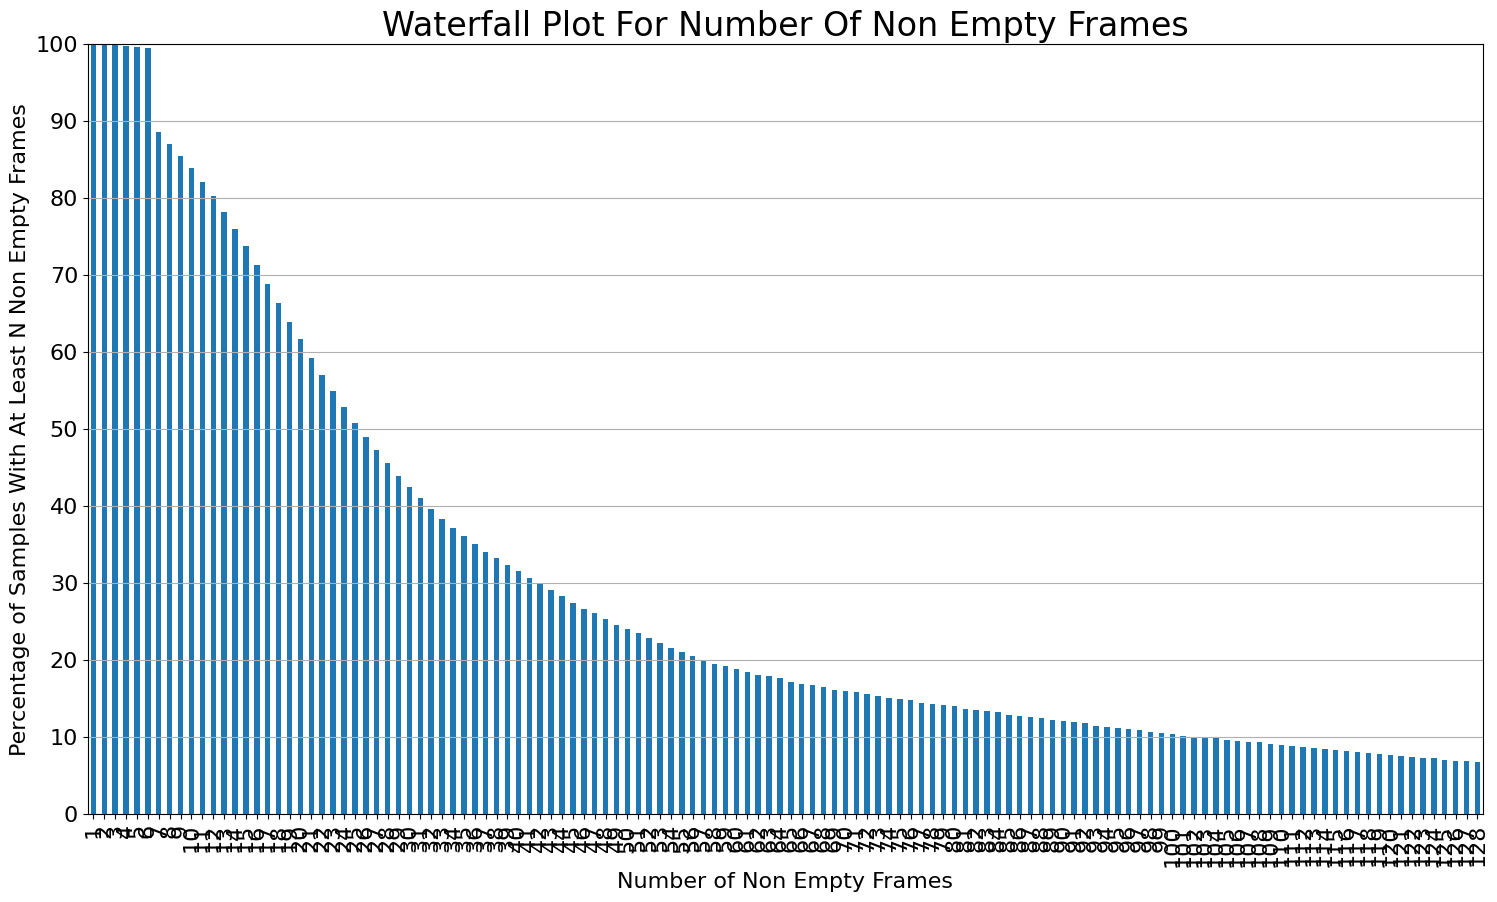

In [22]:
# Vast majority of samples fits has less than 32 non empty frames
N_EMPTY_FRAMES = (NON_EMPTY_FRAME_IDXS_TRAIN != -1).sum(axis=1) 
N_EMPTY_FRAMES_WATERFALL = []
for n in tqdm(range(1,INPUT_SIZE+1)):
    N_EMPTY_FRAMES_WATERFALL.append(sum(N_EMPTY_FRAMES >= n) / len(NON_EMPTY_FRAME_IDXS_TRAIN) * 100)

plt.figure(figsize=(18,10))
plt.title('Waterfall Plot For Number Of Non Empty Frames')
pd.Series(N_EMPTY_FRAMES_WATERFALL).plot(kind='bar')
plt.grid(axis='y')
plt.xticks(np.arange(INPUT_SIZE), np.arange(1, INPUT_SIZE+1))
plt.xlabel('Number of Non Empty Frames', size=16)
plt.yticks(np.arange(0, 100+10, 10))
plt.ylim(0, 100)
plt.ylabel('Percentage of Samples With At Least N Non Empty Frames', size=16)
plt.show() 

# Samples

In [23]:
# Features: Standard Batching + Spatial Augs + Light Masking + Low FPS + Noise
def get_train_batch_all_signs(X, y, NON_EMPTY_FRAME_IDXS, batch_size=32, mixup_alpha=0.0):
    """
    Generator for training batches. MixUp is disabled (0.0) and masking is reduced 
    to prevent starving the pure Transformer of meaningful sequence patterns.
    """
    n_samples = len(X)
    indices = np.arange(n_samples)
    
    while True:
        np.random.shuffle(indices)
        
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            if end_idx - start_idx < 4: 
                continue
                
            batch_idxs = indices[start_idx:end_idx]
            current_batch_size = len(batch_idxs)
            
            X_batch = X[batch_idxs].astype(np.float32) 
            y_batch = tf.one_hot(y[batch_idxs], NUM_CLASSES).numpy()
            non_empty_frame_idxs_batch = NON_EMPTY_FRAME_IDXS[batch_idxs].copy()

            # Spatial Augmentations (Vectorized)
            if np.random.rand() < 0.5:
                scale = np.random.uniform(0.8, 1.2, size=(current_batch_size, 1, 1)).astype(np.float32)
                X_batch = X_batch * scale
                
            if np.random.rand() < 0.5:
                shift = np.random.uniform(-0.05, 0.05, size=(current_batch_size, 1, 1)).astype(np.float32)
                X_batch = X_batch + shift

            # Gaussian Noise
            if np.random.rand() < 0.4:
                X_batch += np.random.normal(0, 0.012, X_batch.shape)

            # Temporal & Feature Masking (Reduced Probabilities)
            for b in range(current_batch_size):
                
                # Feature Masking (Reduced to 10%)
                if np.random.rand() < 0.1:
                    mask_indices = np.random.choice(X.shape[2], int(X.shape[2]*0.1), replace=False)
                    X_batch[b, :, mask_indices] = 0.0

                # Time Masking (Reduced to 20% chance)
                if np.random.rand() < 0.2:
                    len_mask = np.random.randint(5, 15)
                    start_mask = np.random.randint(0, INPUT_SIZE - len_mask)
                    X_batch[b, start_mask:start_mask+len_mask, :] = 0.0
                    non_empty_frame_idxs_batch[b, start_mask:start_mask+len_mask] = -1
                
                # Low FPS Simulation (Reduced to 20% chance)
                if np.random.rand() < 0.2:
                    step = np.random.randint(2, 4) 
                    frame_indices = np.arange(0, INPUT_SIZE, step)
                    
                    kept_frames = X_batch[b, frame_indices, :]
                    kept_masks = non_empty_frame_idxs_batch[b, frame_indices]
                    
                    X_batch[b] = 0.0
                    non_empty_frame_idxs_batch[b] = -1
                    
                    valid_len = len(kept_frames)
                    X_batch[b, :valid_len, :] = kept_frames
                    non_empty_frame_idxs_batch[b, :valid_len] = kept_masks

            # MixUp (Currently bypassed since mixup_alpha=0.0)
            if mixup_alpha > 0 and np.random.rand() < 0.5:
                lam = np.random.beta(mixup_alpha, mixup_alpha)
                perm_indices = np.random.permutation(current_batch_size)
                
                X_batch = lam * X_batch + (1 - lam) * X_batch[perm_indices]
                y_batch = lam * y_batch + (1 - lam) * y_batch[perm_indices]
                
                if lam < 0.5:
                    non_empty_frame_idxs_batch = non_empty_frame_idxs_batch[perm_indices]
            
            yield { 'frames': X_batch, 'non_empty_frame_idxs': non_empty_frame_idxs_batch }, y_batch

In [24]:
dummy_dataset = get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN)
X_batch, y_batch = next(dummy_dataset)

for k, v in X_batch.items():
    print(f'{k} shape: {v.shape}, dtype: {v.dtype}')

# Batch shape/dtype
print(f'y_batch shape: {y_batch.shape}, dtype: {y_batch.dtype}')
# Verify each batch contains each sign exactly N times
display(pd.Series(np.argmax(y_batch, axis=1)).value_counts().to_frame('Counts')) 

frames shape: (32, 128, 609), dtype: float32
non_empty_frame_idxs shape: (32, 128), dtype: float16
y_batch shape: (32, 250), dtype: float32


,Counts
222,2
143,1
31,1
122,1
16,1
137,1
121,1
46,1
62,1
82,1


# Model Config

In [25]:
embed_dim = 256
num_heads = 4
ff_dim = embed_dim * 2

class LearnablePositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, max_len, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.pos_embedding = tf.keras.layers.Embedding(input_dim=max_len, output_dim=embed_dim)

    def call(self, x):
        max_len = tf.shape(x)[1]
        positions = tf.range(start=0, limit=max_len, delta=1)
        return x + self.pos_embedding(positions)

class StochasticDepth(tf.keras.layers.Layer):
    def __init__(self, drop_prob=0.2, **kwargs):
        super().__init__(**kwargs)
        self.drop_prob = drop_prob

    def call(self, x, training=None):
        if not training or self.drop_prob == 0.:
            return x
        
        keep_prob = 1.0 - self.drop_prob
        # Graph-safe shape evaluation
        shape = (tf.shape(x)[0],) + (1,) * (len(x.shape) - 1)
        random_tensor = keep_prob + tf.random.uniform(shape, dtype=x.dtype)
        binary_tensor = tf.floor(random_tensor)
        
        return (x / keep_prob) * binary_tensor

class TransformerBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, drop_rate=0.1, drop_path_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        
        # Proper dimension splitting per head
        head_dim = embed_dim // num_heads 
        self.att = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=head_dim)
        
        # Conformer Trick: Local temporal awareness
        self.local_conv = tf.keras.layers.DepthwiseConv1D(kernel_size=5, padding='same', use_bias=False)
        
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="swish"), 
            tf.keras.layers.Dense(embed_dim),
        ])
        
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        
        self.dropout1 = tf.keras.layers.Dropout(drop_rate)
        self.dropout2 = tf.keras.layers.Dropout(drop_rate)
        self.drop_path = StochasticDepth(drop_path_rate)

    def call(self, inputs, training=None):
        # Global Attention Path
        norm_inputs = self.layernorm1(inputs)
        attn_output = self.att(norm_inputs, norm_inputs, training=training)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = inputs + self.drop_path(attn_output, training=training)
        
        # Local Convolution + FFN Path
        norm_out1 = self.layernorm2(out1)
        local_features = self.local_conv(norm_out1) 
        
        ffn_output = self.ffn(local_features, training=training)
        ffn_output = self.dropout2(ffn_output, training=training)
        
        return out1 + self.drop_path(ffn_output, training=training)

class MaskingLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(MaskingLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        frames, non_empty_frame_idxs = inputs
        mask = tf.math.not_equal(non_empty_frame_idxs, -1)
        mask = tf.cast(mask, dtype=frames.dtype)
        return frames * tf.expand_dims(mask, -1) 

In [26]:
def get_model():
    frames = tf.keras.layers.Input([INPUT_SIZE, N_COLS_FINAL], dtype=tf.float16, name='frames')
    non_empty_frame_idxs = tf.keras.layers.Input([INPUT_SIZE], dtype=tf.float16, name='non_empty_frame_idxs')
    
    x = MaskingLayer(name='input_masking')([frames, non_empty_frame_idxs])
    
    x = tf.keras.layers.Dense(embed_dim, use_bias=False, name='stem_projection')(x)
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6, name='stem_ln')(x)
    
    x = LearnablePositionalEmbedding(INPUT_SIZE, embed_dim)(x)
    
    # Relaxed Stochastic Depth
    x = TransformerBlock(embed_dim, num_heads, ff_dim, drop_rate=0.1, drop_path_rate=0.00, name='transformer_block_1')(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim, drop_rate=0.1, drop_path_rate=0.05, name='transformer_block_2')(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim, drop_rate=0.1, drop_path_rate=0.05, name='transformer_block_3')(x)
    x = TransformerBlock(embed_dim, num_heads, ff_dim, drop_rate=0.1, drop_path_rate=0.10, name='transformer_block_4')(x)
    
    x = tf.keras.layers.GlobalAveragePooling1D(name='gap')(x)
    
    # Reduced Late Dropout
    x = tf.keras.layers.Dropout(0.4, name='late_dropout')(x) 
    
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32', name='classifier')(x)
    
    model = tf.keras.models.Model(inputs=[frames, non_empty_frame_idxs], outputs=outputs)
    
    optimizer = tf.keras.optimizers.AdamW(learning_rate=LR_MAX, weight_decay=WD_RATIO, clipnorm=1.0)
    loss = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)
    
    metrics = [
        tf.keras.metrics.CategoricalAccuracy(name='acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_acc'),
    ]
    
    model.compile(loss=loss, optimizer=optimizer, metrics=metrics)
    
    return model

tf.keras.backend.clear_session()
model = get_model()
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ frames (InputLayer) │ (None, 128, 609)  │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ non_empty_frame_id… │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_masking       │ (None, 128, 609)  │          0 │ frames[0][0],     │
│ (MaskingLayer)      │                   │            │ non_empty_frame_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_projection     │ (None, 128, 256)  │    155,904 │ input_masking[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_ln             │ (None, 128, 256)  │        512 │ stem_projection[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ learnable_position… │ (None, 128, 256)  │     32,768 │ stem_ln[0][0]     │
│ (LearnablePosition… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_1 │ (None, 128, 256)  │    528,384 │ learnable_positi… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_2 │ (None, 128, 256)  │    528,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_3 │ (None, 128, 256)  │    528,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_block_4 │ (None, 128, 256)  │    528,384 │ transformer_bloc… │
│ (TransformerBlock)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gap                 │ (None, 256)       │          0 │ transformer_bloc… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ late_dropout        │ (None, 256)       │          0 │ gap[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ classifier (Dense)  │ (None, 250)       │     64,250 │ late_dropout[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,366,970 (9.03 MB)

 Trainable params: 2,366,970 (9.03 MB)

 Non-trainable params: 0 (0.00 B)

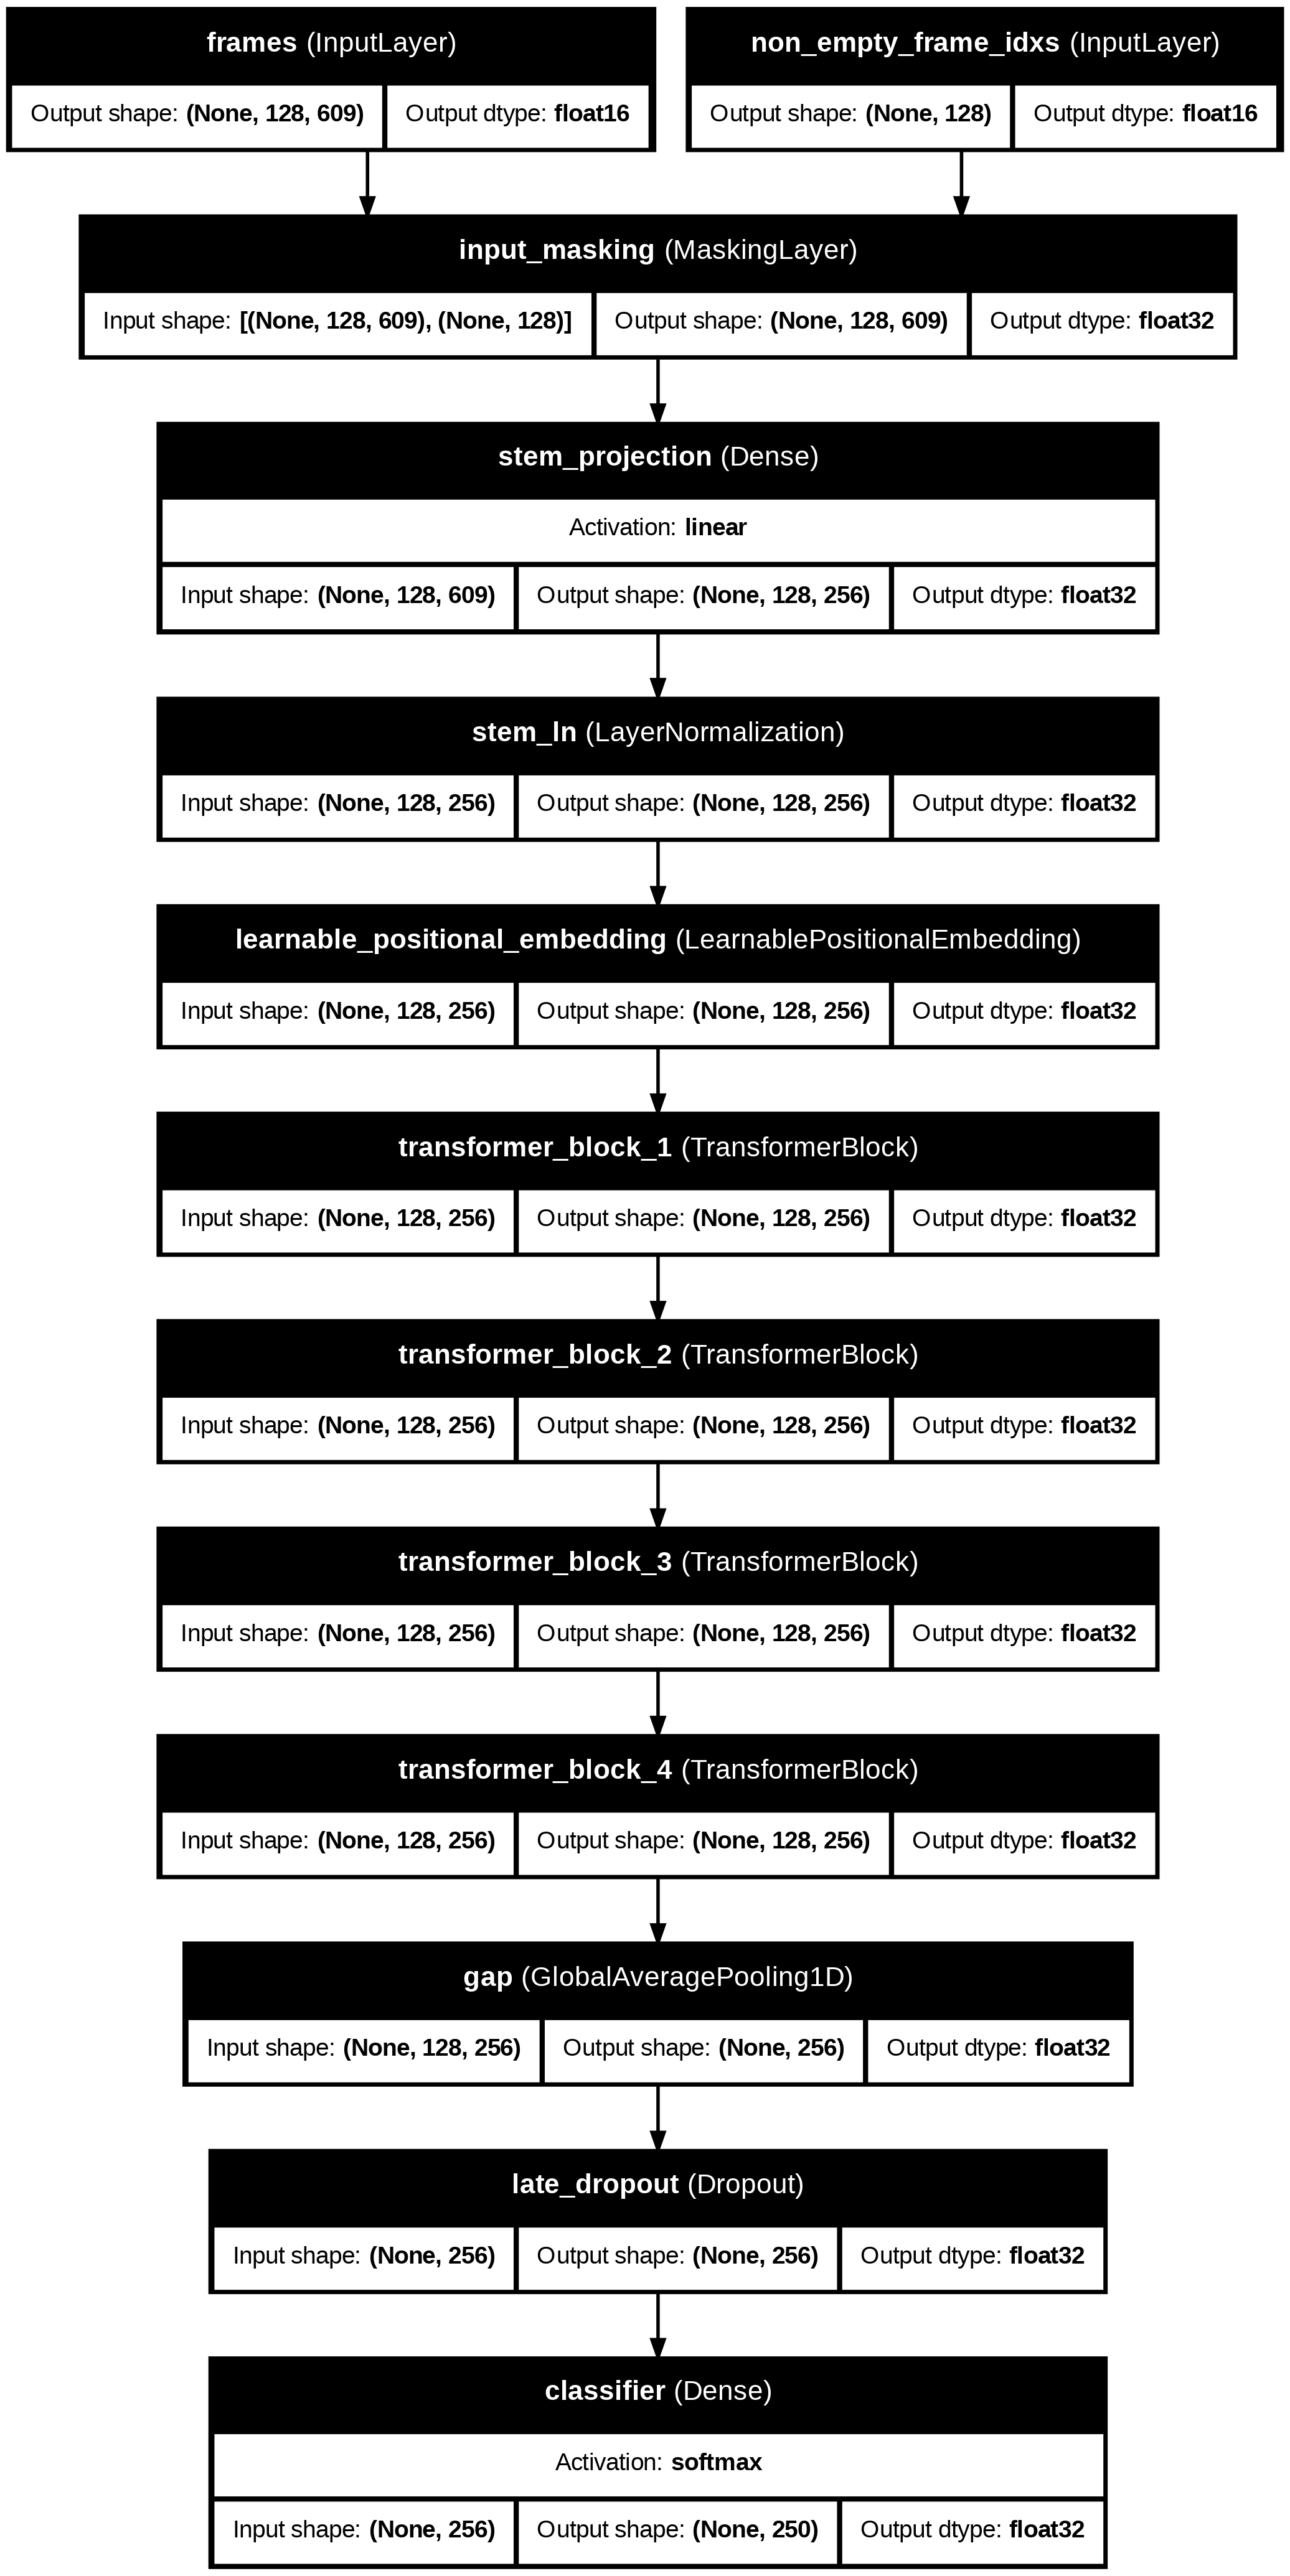

In [27]:
tf.keras.utils.plot_model(model, show_shapes=True, show_dtype=True, show_layer_names=True, expand_nested=True, show_layer_activations=True) 

# No NaN Predictions

In [28]:
if TRAIN_MODEL:
    y_pred = model.predict_on_batch(X_batch)
    nan_count = np.isnan(y_pred).sum()
    print(f'# NaN Values In Prediction: {nan_count}')
    if nan_count > 0:
        raise ValueError("Stability Error: NaNs detected in initial forward pass. Check normalization.")

I0000 00:00:1772635842.129341      72 service.cc:152] XLA service 0x7d979dc13160 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772635842.129395      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772635842.490526      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772635844.723536      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


# NaN Values In Prediction: 0


# Weight Initialization

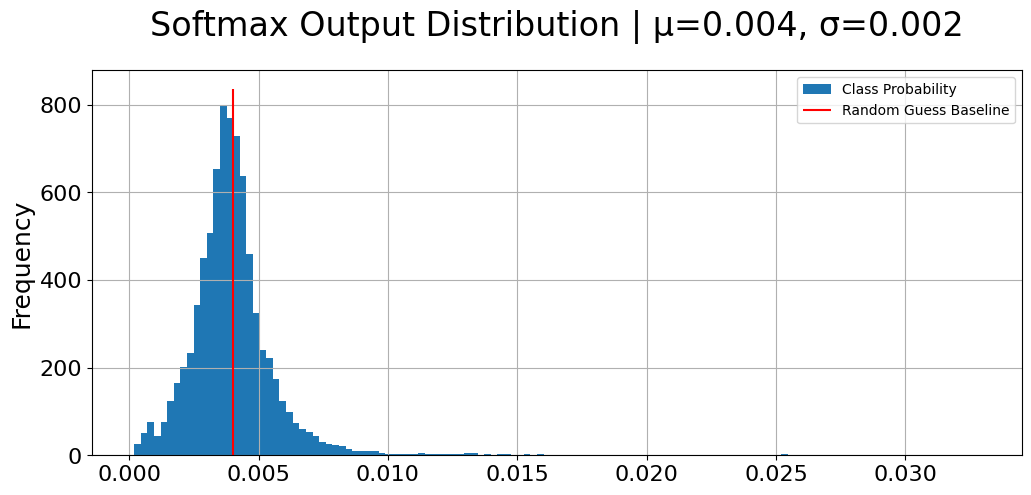

In [29]:
if TRAIN_MODEL:
    plt.figure(figsize=(12,5))
    plt.title(f'Softmax Output Distribution | µ={y_pred.mean():.3f}, σ={y_pred.std():.3f}', pad=25)
    pd.Series(y_pred.flatten()).plot(kind='hist', bins=128, label='Class Probability')
    plt.vlines([1 / NUM_CLASSES], 0, plt.ylim()[1], color='red', label='Random Guess Baseline')
    plt.grid()
    plt.legend()
    plt.show() 

In [30]:
if USE_VAL:
    # Verify validation distribution covers the full 250-sign vocabulary
    unique_val_signs = pd.Series(y_val).nunique()
    print(f'# Unique Signs in Validation Set: {unique_val_signs}')
    if unique_val_signs < NUM_CLASSES:
        print("Warning: Validation set is missing signs")

# Unique Signs in Validation Set: 250


In [31]:
# Memory Optimization: Generator to stream validation data without a "Copy Spike" OOM.
def get_val_batch(X, y, NON_EMPTY_FRAME_IDXS, batch_size=32):
    n_samples = len(X)
    indices = np.arange(n_samples)
    while True:
        for start_idx in range(0, n_samples, batch_size):
            end_idx = min(start_idx + batch_size, n_samples)
            batch_idxs = indices[start_idx:end_idx]
            X_batch = X[batch_idxs].astype(np.float32)
            y_batch = tf.one_hot(y[batch_idxs], NUM_CLASSES).numpy()
            non_empty_frame_idxs_batch = NON_EMPTY_FRAME_IDXS[batch_idxs]
            yield { 'frames': X_batch, 'non_empty_frame_idxs': non_empty_frame_idxs_batch }, y_batch

In [32]:
# Synchronized Training Engine
# Optimized for pure Transformers: Requires Linear Warmup + Cosine Decay

STEPS_PER_EPOCH = len(X_train) // BATCH_SIZE
VAL_STEPS = len(X_val) // BATCH_SIZE if USE_VAL else None
TOTAL_STEPS = N_EPOCHS * STEPS_PER_EPOCH
WARMUP_STEPS = N_WARMUP_EPOCHS * STEPS_PER_EPOCH

class WarmUpCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    """
    Linearly increases learning rate for WARMUP_STEPS, 
    then applies cosine decay to a minimum learning rate.
    """
    def __init__(self, init_lr, max_lr, warmup_steps, total_steps):
        super().__init__()
        self.init_lr = tf.cast(init_lr, tf.float32)
        self.max_lr = tf.cast(max_lr, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)
        self.total_steps = tf.cast(total_steps, tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        
        # Linear Warmup Phase
        warmup_lr = self.init_lr + (self.max_lr - self.init_lr) * (step / self.warmup_steps)
        
        # Cosine Decay Phase
        decay_steps = tf.maximum(self.total_steps - self.warmup_steps, 1.0)
        step_after_warmup = tf.maximum(step - self.warmup_steps, 0.0)
        cosine_decay = 0.5 * (1.0 + tf.math.cos(math.pi * step_after_warmup / decay_steps))
        decayed_lr = cosine_decay * self.max_lr
        
        return tf.where(step < self.warmup_steps, warmup_lr, decayed_lr)

# Initialize custom learning rate schedule
lr_schedule = WarmUpCosineDecay(
    init_lr=1e-6, 
    max_lr=LR_MAX, 
    warmup_steps=WARMUP_STEPS, 
    total_steps=TOTAL_STEPS
)

# AdamW Optimizer with Weight Decay
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule, 
    weight_decay=WD_RATIO, 
    clipnorm=1.0 # Protects against gradient spikes in mixed_float16
)

model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    optimizer=optimizer,
    metrics=['acc', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top_5_acc')]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=25, # Transformers often need longer patience to settle
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'transformer_model.weights.h5', 
        save_best_only=True, 
        save_weights_only=True
    )
]

if TRAIN_MODEL:
    history = model.fit(
        # Training Generator (Applies spatial/temporal augs on CPU)
        x=get_train_batch_all_signs(X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN, batch_size=BATCH_SIZE),
        steps_per_epoch=STEPS_PER_EPOCH,
        
        # Validation Generator (Streamed to avoid OOM on P100)
        validation_data=get_val_batch(X_val, y_val, NON_EMPTY_FRAME_IDXS_VAL, batch_size=BATCH_SIZE) if USE_VAL else None,
        validation_steps=VAL_STEPS if USE_VAL else None,
        
        epochs=N_EPOCHS,
        callbacks=callbacks,
        verbose=VERBOSE
    ) 

Epoch 1/200
1253/1253 - 193s - 154ms/step - acc: 0.0086 - loss: 5.4981 - top_5_acc: 0.0390 - val_acc: 0.0382 - val_loss: 5.1641 - val_top_5_acc: 0.1039
Epoch 2/200
1253/1253 - 179s - 143ms/step - acc: 0.0551 - loss: 4.8375 - top_5_acc: 0.1952 - val_acc: 0.2192 - val_loss: 3.9307 - val_top_5_acc: 0.5384
Epoch 3/200
1253/1253 - 157s - 125ms/step - acc: 0.1479 - loss: 4.1829 - top_5_acc: 0.4101 - val_acc: 0.3432 - val_loss: 3.2760 - val_top_5_acc: 0.6810
Epoch 4/200
1253/1253 - 160s - 128ms/step - acc: 0.2518 - loss: 3.6979 - top_5_acc: 0.5592 - val_acc: 0.4475 - val_loss: 2.8604 - val_top_5_acc: 0.7638
Epoch 5/200
1253/1253 - 157s - 126ms/step - acc: 0.3335 - loss: 3.3602 - top_5_acc: 0.6485 - val_acc: 0.5108 - val_loss: 2.5945 - val_top_5_acc: 0.8214
Epoch 6/200
1253/1253 - 154s - 123ms/step - acc: 0.4100 - loss: 3.0894 - top_5_acc: 0.7095 - val_acc: 0.5341 - val_loss: 2.4735 - val_top_5_acc: 0.8420
Epoch 7/200
1253/1253 - 158s - 126ms/step - acc: 0.4674 - loss: 2.8863 - top_5_acc: 0.75

In [33]:
import pandas as pd
from IPython.display import FileLink

# history.history is a dictionary containing the metrics
history_df = pd.DataFrame(history.history)

# Name the index 'epoch' for clarity
history_df.index.name = 'epoch'

# Save to CSV
file_name = 'training_history_post_train.csv'
history_df.to_csv(file_name)

print(f"Training history saved to {file_name}")

# Create a download link
display(FileLink(file_name))

Training history saved to training_history_post_train.csv


/kaggle/working/training_history_post_train.csv

In [34]:
# Aggressive cleanup is necessary on P100 to prepare for the high-memory inference pass.
if 'X_train' in globals():
    del X_train, y_train, NON_EMPTY_FRAME_IDXS_TRAIN
gc.collect()
try:
    import ctypes
    ctypes.CDLL("libc.so.6").malloc_trim(0)
    print("System memory explicitly released.")
except:
    pass

System memory explicitly released.


# Evaluation - Comprehensive Report for 250 Classes

In [35]:
# Streamed Inference: Decouples prediction from RAM limits.
if USE_VAL:
    print("Running inference on validation set...")
    
    y_val_pred = np.zeros(len(X_val), dtype=np.int16)
    y_val_probs = np.zeros((len(X_val), 250), dtype=np.float32)  
    chunk_size = 1000 
    
    for i in tqdm(range(int(np.ceil(len(X_val) / chunk_size))), desc="Inference"):
        start, end = i * chunk_size, min((i + 1) * chunk_size, len(X_val))
        probs = model.predict(
            {'frames': X_val[start:end], 'non_empty_frame_idxs': NON_EMPTY_FRAME_IDXS_VAL[start:end]}, 
            batch_size=BATCH_SIZE, verbose=0
        )
        y_val_probs[start:end] = probs  # STORE PROBABILITIES
        y_val_pred[start:end] = probs.argmax(axis=1).astype(np.int16)
        del probs
        gc.collect() 
    
    print(f"Inference complete. Predictions shape: {y_val_pred.shape}")
    print(f"Probabilities shape: {y_val_probs.shape}")  # VERIFY

Running inference on validation set...


Inference:   0%|          | 0/15 [00:00<?, ?it/s]

Inference complete. Predictions shape: (14248,)
Probabilities shape: (14248, 250)


## 1. Top-1 vs Top-5 Accuracy

In [36]:
if USE_VAL:
    # Top-1 Accuracy
    top1_accuracy = sklearn.metrics.accuracy_score(y_val, y_val_pred)
    
    # Top-5 Accuracy
    top5_preds = np.argsort(y_val_probs, axis=1)[:, -5:]  # Get indices of top 5 predictions
    top5_correct = np.array([y_val[i] in top5_preds[i] for i in range(len(y_val))])
    top5_accuracy = top5_correct.mean()
    
    print("="*60)
    print("ACCURACY METRICS FOR 250-CLASS CLASSIFICATION")
    print("="*60)
    print(f"Top-1 Accuracy: {top1_accuracy:.4f} ({top1_accuracy*100:.2f}%)")
    print(f"Top-5 Accuracy: {top5_accuracy:.4f} ({top5_accuracy*100:.2f}%)")
    print(f"\nInterpretation:")
    print(f"  - The model predicts the exact correct sign {top1_accuracy*100:.2f}% of the time")
    print(f"  - The correct sign appears in the model's top 5 guesses {top5_accuracy*100:.2f}% of the time")
    print(f"  - Top-5 improvement: +{(top5_accuracy - top1_accuracy)*100:.2f} percentage points")
    print("="*60)

ACCURACY METRICS FOR 250-CLASS CLASSIFICATION
Top-1 Accuracy: 0.7412 (74.12%)
Top-5 Accuracy: 0.9210 (92.10%)

Interpretation:
  - The model predicts the exact correct sign 74.12% of the time
  - The correct sign appears in the model's top 5 guesses 92.10% of the time
  - Top-5 improvement: +17.99 percentage points


## 2. Confusion Matrix - Top 10 Most Confused Pairs


TOP 10 MOST CONFUSED SIGN PAIRS


,confusion_pair,count,true_sign,pred_sign
0,awake → wake,40,awake,wake
1,mouth → lips,37,mouth,lips
2,nap → sleep,33,nap,sleep
3,pen → pencil,25,pen,pencil
4,mitten → many,22,mitten,many
5,carrot → yes,20,carrot,yes
6,listen → hear,20,listen,hear
7,find → frenchfries,19,find,frenchfries
8,goose → bird,19,goose,bird
9,underwear → hen,19,underwear,hen


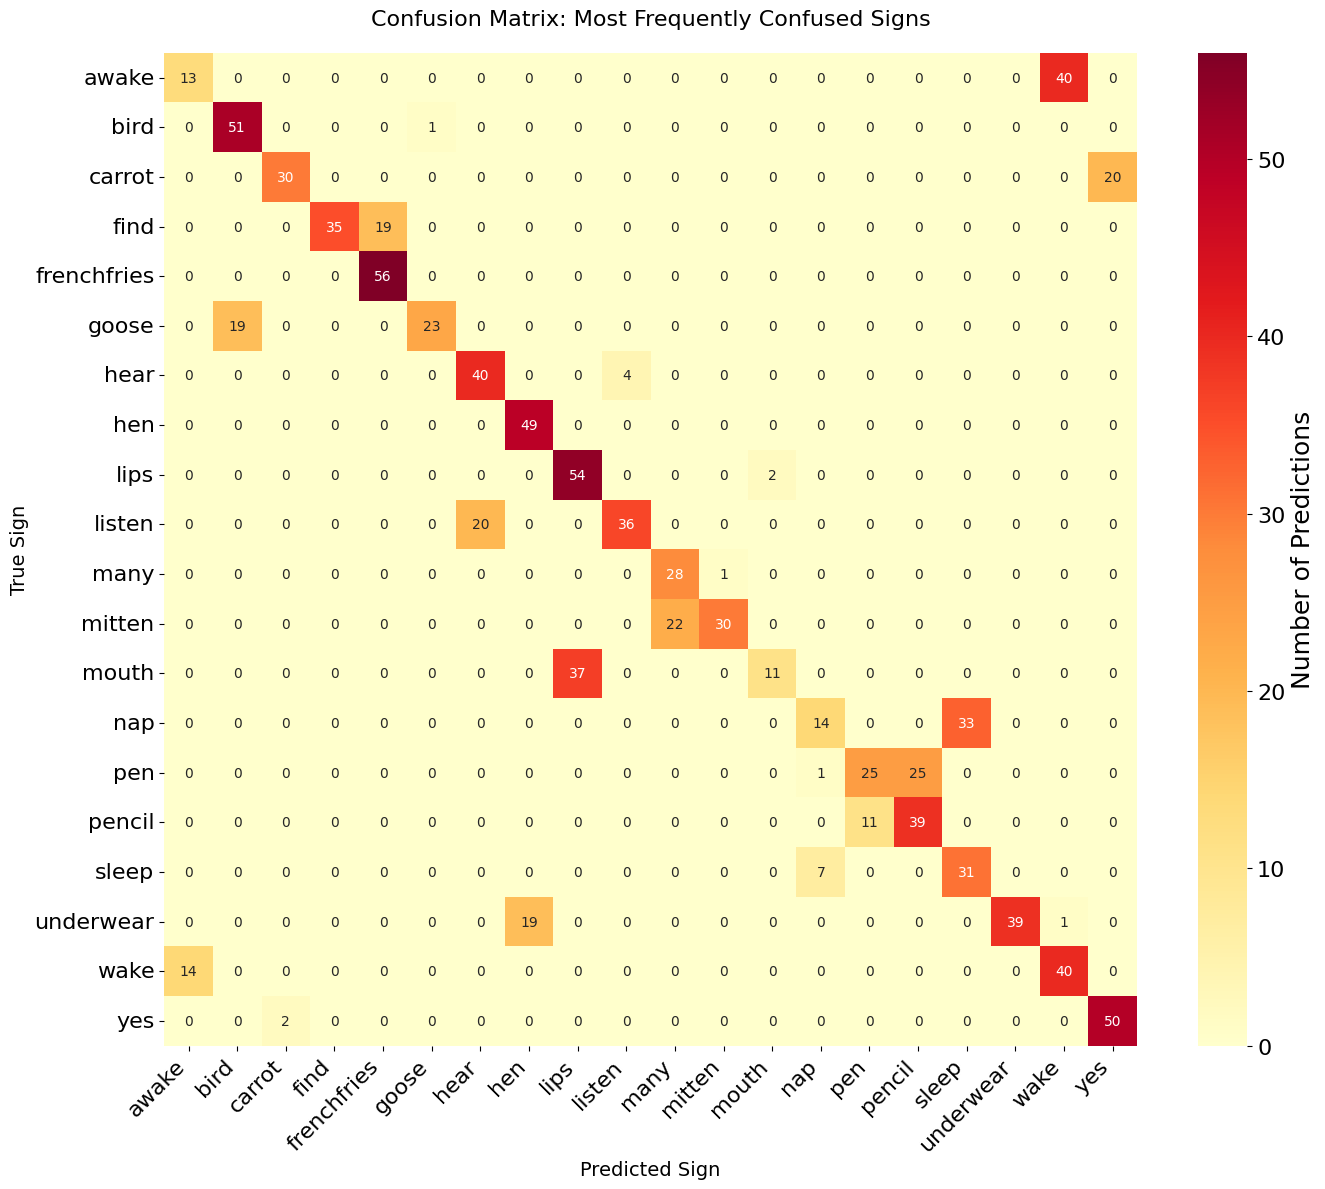


Insights:
  - Look for pairs with similar handshapes or movements
  - Symmetric confusions may indicate visual similarity
  - High confusion counts suggest challenging distinction tasks


In [37]:
if USE_VAL:
    # Compute full confusion matrix
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_val, y_val_pred)
    
    # Find top 10 most confused pairs (excluding diagonal)
    cm_no_diag = cm.copy()
    np.fill_diagonal(cm_no_diag, 0)
    
    # Get indices of top confusions
    top_confusions = []
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm_no_diag[i, j] > 0:
                top_confusions.append({
                    'true_class': i,
                    'pred_class': j,
                    'count': cm_no_diag[i, j],
                    'true_sign': ORD2SIGN[i],
                    'pred_sign': ORD2SIGN[j]
                })
    
    # Sort by count and get top 10
    top_confusions = sorted(top_confusions, key=lambda x: x['count'], reverse=True)[:10]
    
    print("\n" + "="*80)
    print("TOP 10 MOST CONFUSED SIGN PAIRS")
    print("="*80)
    
    confusion_df = pd.DataFrame(top_confusions)
    confusion_df['confusion_pair'] = confusion_df.apply(
        lambda row: f"{row['true_sign']} → {row['pred_sign']}", axis=1
    )
    
    display(confusion_df[['confusion_pair', 'count', 'true_sign', 'pred_sign']])
    
    # Plot confusion heatmap for top confused pairs
    if len(top_confusions) > 0:
        # Get unique classes involved in top confusions
        confused_classes = set()
        for conf in top_confusions:
            confused_classes.add(conf['true_class'])
            confused_classes.add(conf['pred_class'])
        confused_classes = sorted(list(confused_classes))[:20]  # Limit to 20 for readability
        
        # Create sub-confusion matrix
        cm_subset = cm[np.ix_(confused_classes, confused_classes)]
        labels_subset = [ORD2SIGN[i] for i in confused_classes]
        
        plt.figure(figsize=(14, 12))
        sns.heatmap(cm_subset, annot=True, fmt='d', cmap='YlOrRd', 
                    xticklabels=labels_subset, yticklabels=labels_subset,
                    cbar_kws={'label': 'Number of Predictions'})
        plt.title('Confusion Matrix: Most Frequently Confused Signs', fontsize=16, pad=20)
        plt.xlabel('Predicted Sign', fontsize=14)
        plt.ylabel('True Sign', fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
        
        print("\nInsights:")
        print("  - Look for pairs with similar handshapes or movements")
        print("  - Symmetric confusions may indicate visual similarity")
        print("  - High confusion counts suggest challenging distinction tasks")

In [38]:
def print_classification_report():
    report_labels = [ORD2SIGN[i] for i in range(NUM_CLASSES)]
    report = sklearn.metrics.classification_report(
        y_val, y_val_pred, target_names=report_labels, output_dict=True
    )
    df_report = pd.DataFrame(report).T.round(2)
    display(df_report.sort_values('f1-score', ascending=False).head(20))
    display(df_report.tail(3))

if USE_VAL:
    print_classification_report() 

,precision,recall,f1-score,support
food,0.98,0.98,0.98,57.0
police,0.95,0.98,0.97,60.0
nose,0.97,0.97,0.97,58.0
airplane,0.96,0.95,0.96,57.0
shhh,0.94,0.98,0.96,60.0
flower,1.00,0.91,0.95,57.0
clown,0.95,0.95,0.95,61.0
for,0.95,0.93,0.94,57.0
brown,0.89,1.00,0.94,58.0
mouse,0.96,0.92,0.94,60.0


,precision,recall,f1-score,support
accuracy,0.74,0.74,0.74,0.74
macro avg,0.75,0.74,0.74,14248.00
weighted avg,0.75,0.74,0.74,14248.00


## 3. Per-Class F1 Score - Best and Worst Performing Signs


TOP 5 BEST PERFORMING SIGNS (Highest F1 Score)


,precision,recall,f1-score,support
food,0.9825,0.9825,0.9825,57.0
police,0.9516,0.9833,0.9672,60.0
nose,0.9655,0.9655,0.9655,58.0
shhh,0.9365,0.9833,0.9593,60.0
airplane,0.9643,0.9474,0.9558,57.0



TOP 5 WORST PERFORMING SIGNS (Lowest F1 Score)


,precision,recall,f1-score,support
give,0.4194,0.2453,0.3095,53.0
nap,0.5185,0.2154,0.3043,65.0
awake,0.3939,0.2281,0.2889,57.0
mouth,0.6471,0.1833,0.2857,60.0
go,0.5000,0.1698,0.2535,53.0


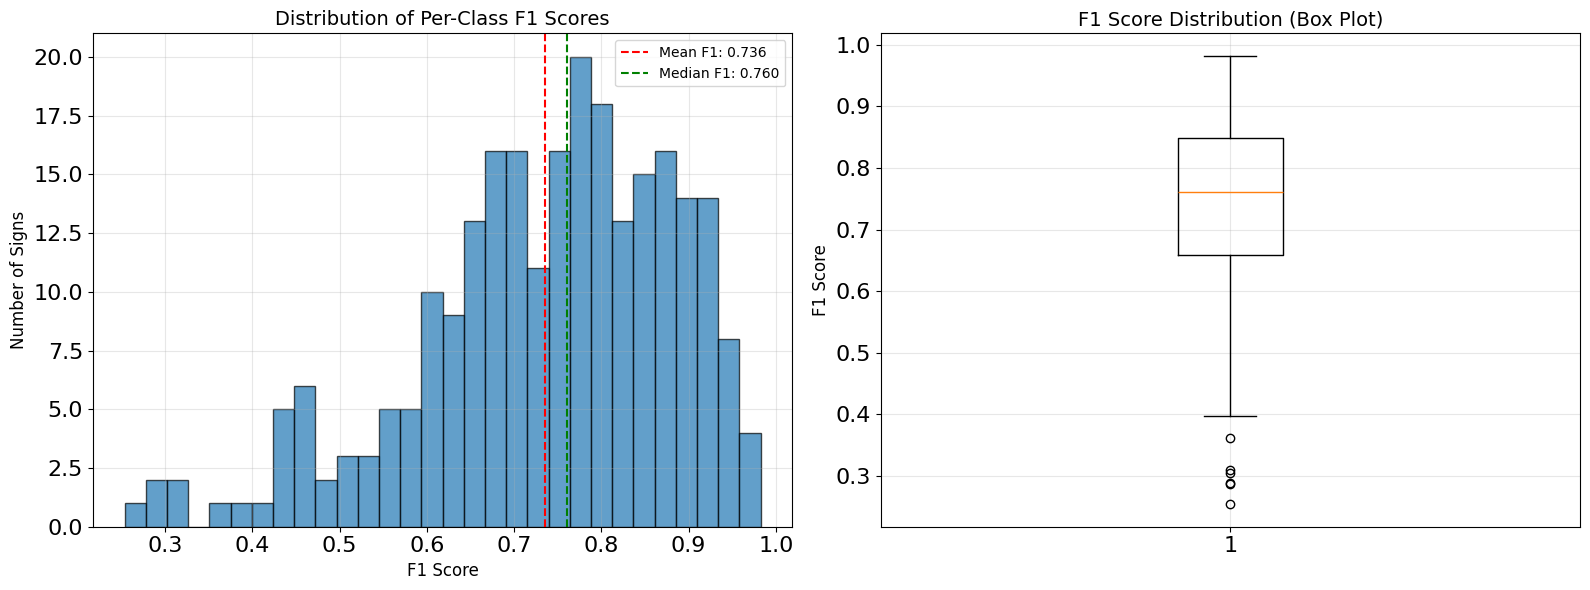


F1 SCORE STATISTICS ACROSS ALL 250 CLASSES
Mean F1 Score:   0.7357
Median F1 Score: 0.7603
Std Dev:         0.1487
Min F1 Score:    0.2535
Max F1 Score:    0.9825

Classes with F1 = 0.0: 0
Classes with F1 > 0.9: 29
Classes with F1 > 0.8: 91


In [39]:
if USE_VAL:
    from sklearn.metrics import classification_report, f1_score
    
    # Get per-class F1 scores
    report_labels = [ORD2SIGN[i] for i in range(NUM_CLASSES)]
    report = classification_report(
        y_val, y_val_pred, target_names=report_labels, output_dict=True, zero_division=0
    )
    
    # Convert to DataFrame for easier manipulation
    df_report = pd.DataFrame(report).T
    
    # Filter only class-level metrics (exclude macro/micro/weighted averages)
    class_metrics = df_report[~df_report.index.isin(['accuracy', 'macro avg', 'micro avg', 'weighted avg'])].copy()
    class_metrics = class_metrics.sort_values('f1-score', ascending=False)
    
    print("\n" + "="*80)
    print("TOP 5 BEST PERFORMING SIGNS (Highest F1 Score)")
    print("="*80)
    best_5 = class_metrics.head(5)
    best_5_display = best_5[['precision', 'recall', 'f1-score', 'support']].round(4)
    display(best_5_display)
    
    print("\n" + "="*80)
    print("TOP 5 WORST PERFORMING SIGNS (Lowest F1 Score)")
    print("="*80)
    worst_5 = class_metrics.tail(5)
    worst_5_display = worst_5[['precision', 'recall', 'f1-score', 'support']].round(4)
    display(worst_5_display)
    
    # Visualize F1 score distribution
    plt.figure(figsize=(16, 6))
    
    # Histogram of F1 scores
    plt.subplot(1, 2, 1)
    plt.hist(class_metrics['f1-score'], bins=30, edgecolor='black', alpha=0.7)
    plt.axvline(class_metrics['f1-score'].mean(), color='red', linestyle='--', 
                label=f'Mean F1: {class_metrics["f1-score"].mean():.3f}')
    plt.axvline(class_metrics['f1-score'].median(), color='green', linestyle='--', 
                label=f'Median F1: {class_metrics["f1-score"].median():.3f}')
    plt.xlabel('F1 Score', fontsize=12)
    plt.ylabel('Number of Signs', fontsize=12)
    plt.title('Distribution of Per-Class F1 Scores', fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Box plot of F1 scores
    plt.subplot(1, 2, 2)
    plt.boxplot(class_metrics['f1-score'], vert=True)
    plt.ylabel('F1 Score', fontsize=12)
    plt.title('F1 Score Distribution (Box Plot)', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print("\n" + "="*80)
    print("F1 SCORE STATISTICS ACROSS ALL 250 CLASSES")
    print("="*80)
    print(f"Mean F1 Score:   {class_metrics['f1-score'].mean():.4f}")
    print(f"Median F1 Score: {class_metrics['f1-score'].median():.4f}")
    print(f"Std Dev:         {class_metrics['f1-score'].std():.4f}")
    print(f"Min F1 Score:    {class_metrics['f1-score'].min():.4f}")
    print(f"Max F1 Score:    {class_metrics['f1-score'].max():.4f}")
    print(f"\nClasses with F1 = 0.0: {(class_metrics['f1-score'] == 0).sum()}")
    print(f"Classes with F1 > 0.9: {(class_metrics['f1-score'] > 0.9).sum()}")
    print(f"Classes with F1 > 0.8: {(class_metrics['f1-score'] > 0.8).sum()}")
    print("="*80)

## 4. Analysis: Why Does the Model Fail?

In [40]:
if USE_VAL:
    # Analyze characteristics of best and worst performing signs
    print("\n" + "="*80)
    print("FAILURE ANALYSIS")
    print("="*80)
    
    # Get sample counts for worst performing signs
    worst_signs = worst_5.index.tolist()
    best_signs = best_5.index.tolist()
    
    print("\nHypotheses for poor performance:")
    print("  1. Sample Size: Check if worst signs have fewer training examples")
    print("  2. Visual Similarity: Worst signs may be visually similar to others")
    print("  3. Motion Complexity: Short/simple signs may lack distinctive features")
    print("  4. Handshape Similarity: Similar handshapes between confused pairs")
    
    # Check support (number of samples) for worst vs best
    print("\nSample Support Comparison:")
    print(f"  Average support (worst 5): {worst_5['support'].mean():.1f}")
    print(f"  Average support (best 5):  {best_5['support'].mean():.1f}")
    
    # Recommendations
    print("\n" + "="*80)
    print("RECOMMENDATIONS FOR IMPROVEMENT")
    print("="*80)
    print("1. Data Augmentation:")
    print("   - Focus on worst-performing classes with temporal augmentations")
    print("   - Apply hand-specific augmentations for similar handshapes")
    print("\n2. Model Architecture:")
    print("   - Consider attention mechanisms to focus on discriminative features")
    print("   - Add auxiliary losses for confused pairs")
    print("\n3. Training Strategy:")
    print("   - Use class weights to handle imbalanced classes")
    print("   - Implement hard negative mining for confused pairs")
    print("\n4. Feature Engineering:")
    print("   - Extract hand-shape specific features")
    print("   - Incorporate motion trajectory features")
    print("="*80)


FAILURE ANALYSIS

Hypotheses for poor performance:
  1. Sample Size: Check if worst signs have fewer training examples
  2. Visual Similarity: Worst signs may be visually similar to others
  3. Motion Complexity: Short/simple signs may lack distinctive features
  4. Handshape Similarity: Similar handshapes between confused pairs

Sample Support Comparison:
  Average support (worst 5): 57.6
  Average support (best 5):  58.4

RECOMMENDATIONS FOR IMPROVEMENT
1. Data Augmentation:
   - Focus on worst-performing classes with temporal augmentations
   - Apply hand-specific augmentations for similar handshapes

2. Model Architecture:
   - Consider attention mechanisms to focus on discriminative features
   - Add auxiliary losses for confused pairs

3. Training Strategy:
   - Use class weights to handle imbalanced classes
   - Implement hard negative mining for confused pairs

4. Feature Engineering:
   - Extract hand-shape specific features
   - Incorporate motion trajectory features


## 5. Complete Classification Report (Optional)

In [41]:
if USE_VAL:
    # This cell is optional - displays full report for all 250 classes
    # Uncomment to see detailed metrics for every sign
    
    print("\n" + "="*80)
    print("COMPLETE CLASSIFICATION REPORT (All 250 Classes)")
    print("="*80)
    print("Note: This is a comprehensive view. Scroll to see all classes.")
    print("="*80 + "\n")
    
    full_report = class_metrics.sort_values('f1-score', ascending=False)
    display(full_report[['precision', 'recall', 'f1-score', 'support']].round(4))


COMPLETE CLASSIFICATION REPORT (All 250 Classes)
Note: This is a comprehensive view. Scroll to see all classes.



,precision,recall,f1-score,support
food,0.9825,0.9825,0.9825,57.0
police,0.9516,0.9833,0.9672,60.0
nose,0.9655,0.9655,0.9655,58.0
shhh,0.9365,0.9833,0.9593,60.0
airplane,0.9643,0.9474,0.9558,57.0
...,...,...,...,...
give,0.4194,0.2453,0.3095,53.0
nap,0.5185,0.2154,0.3043,65.0
awake,0.3939,0.2281,0.2889,57.0
mouth,0.6471,0.1833,0.2857,60.0


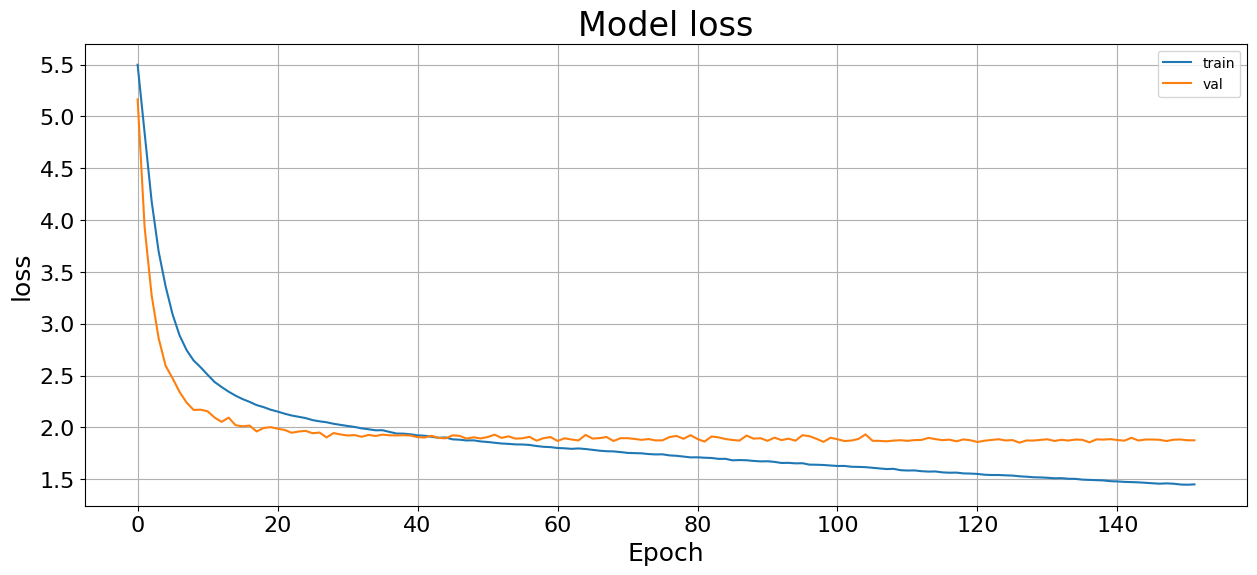

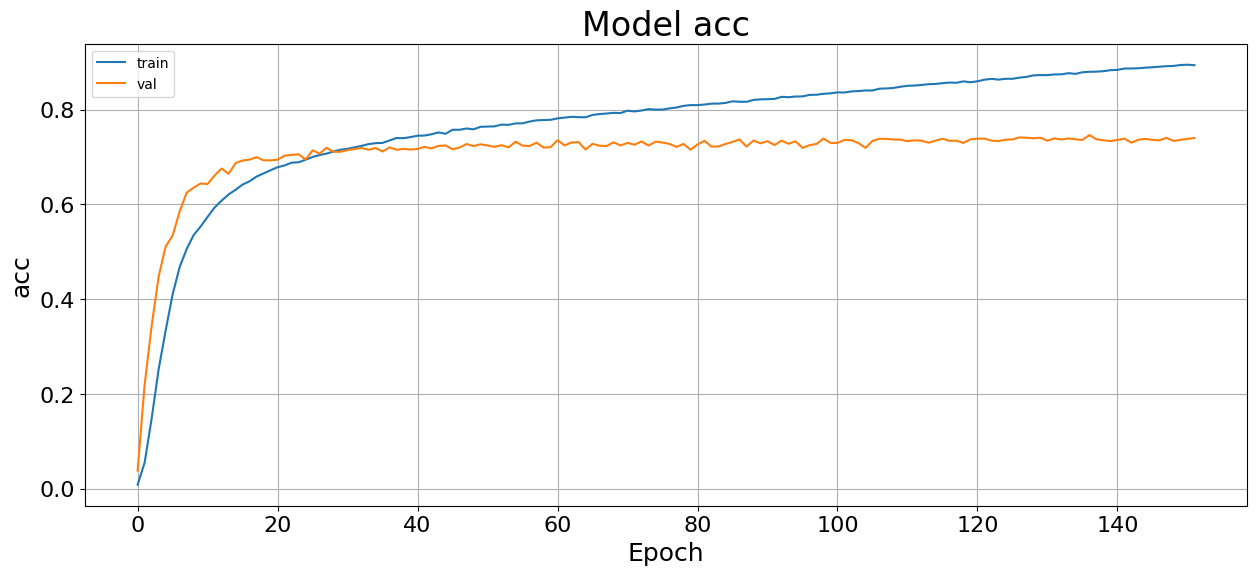

In [42]:
def plot_history_metric(metric):
    plt.figure(figsize=(15, 6))
    plt.plot(history.history[metric], label='train')
    if f'val_{metric}' in history.history:
        plt.plot(history.history[f'val_{metric}'], label='val')
    plt.title(f'Model {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()

if TRAIN_MODEL:
    plot_history_metric('loss')
    plot_history_metric('acc')

In [43]:
def get_config(self):
    """Required for model serialization - allows model.save() to work"""
    return {
        'lr_max': float(self.lr_max),
        'warmup_steps': int(self.warmup_steps),
        'total_steps': int(self.total_steps),
        'lr_min': float(self.lr_min)
    }

In [44]:
if TRAIN_MODEL:
    # Save model weights (always works)
    model.save_weights('asl_transformer_weights.weights.h5')
    print("Model weights saved successfully")
    
    # Try to save full model
    try:
        model.save('asl_transformer_model.keras')
        print("Full model saved successfully")
    except Exception as e:
        print("Note: Full model save failed, but weights were saved")

Model weights saved successfully
Note: Full model save failed, but weights were saved


In [45]:
# Rebuild model architecture (same code as training)
model = get_model()

# Load weights
model.load_weights('asl_transformer_weights.weights.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 149 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
